In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import os

os.makedirs("images", exist_ok=True)
print("Images folder:", os.path.abspath("images"))

Images folder: C:\Users\vshar\AIML\Ai training\tasks\Random forest and naive bayes\images


In [158]:
df = pd.read_csv("usa_rain_prediction_dataset_2024_2025.csv")

In [159]:
df.head()

,Date,Location,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure,Rain Tomorrow
0,2024-01-01,New York,87.524795,75.655455,28.379506,0.000000,69.617966,1026.030278,0
1,2024-01-02,New York,83.259325,28.712617,12.436433,0.526995,41.606048,995.962065,0
2,2024-01-03,New York,80.943050,64.740043,14.184831,0.916884,77.364763,980.796739,1
3,2024-01-04,New York,78.097552,59.738984,19.444029,0.094134,52.541196,979.012163,0
4,2024-01-05,New York,37.059963,34.766784,3.689661,1.361272,85.584000,1031.790859,0


In [160]:
df.shape

(73100, 9)

In [161]:
df.columns

Index(['Date', 'Location', 'Temperature', 'Humidity', 'Wind Speed',
       'Precipitation', 'Cloud Cover', 'Pressure', 'Rain Tomorrow'],
      dtype='object')

In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           73100 non-null  object 
 1   Location       73100 non-null  object 
 2   Temperature    73100 non-null  float64
 3   Humidity       73100 non-null  float64
 4   Wind Speed     73100 non-null  float64
 5   Precipitation  73100 non-null  float64
 6   Cloud Cover    73100 non-null  float64
 7   Pressure       73100 non-null  float64
 8   Rain Tomorrow  73100 non-null  int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 5.0+ MB


In [163]:
df.isnull().sum()

Date             0
Location         0
Temperature      0
Humidity         0
Wind Speed       0
Precipitation    0
Cloud Cover      0
Pressure         0
Rain Tomorrow    0
dtype: int64

In [164]:
df.duplicated().sum()

np.int64(0)

In [165]:
df.dtypes

Date              object
Location          object
Temperature      float64
Humidity         float64
Wind Speed       float64
Precipitation    float64
Cloud Cover      float64
Pressure         float64
Rain Tomorrow      int64
dtype: object

In [166]:
print(df.columns.tolist())

['Date', 'Location', 'Temperature', 'Humidity', 'Wind Speed', 'Precipitation', 'Cloud Cover', 'Pressure', 'Rain Tomorrow']


In [167]:
features = [
    'Humidity',
    'Temperature',
    'Wind Speed',
    'Pressure'
]
target = 'Rain Tomorrow'
data = df[features + [target]].copy()
data.head()

,Humidity,Temperature,Wind Speed,Pressure,Rain Tomorrow
0,75.655455,87.524795,28.379506,1026.030278,0
1,28.712617,83.259325,12.436433,995.962065,0
2,64.740043,80.943050,14.184831,980.796739,1
3,59.738984,78.097552,19.444029,979.012163,0
4,34.766784,37.059963,3.689661,1031.790859,0


In [168]:
data.describe()

,Humidity,Temperature,Wind Speed,Pressure,Rain Tomorrow
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,59.875041,65.182270,15.017946,1005.176013,0.220410
std,23.066115,20.205793,8.668729,20.203889,0.414526
min,20.000272,30.000766,0.000712,970.000919,0.000000
25%,39.800732,47.678968,7.485182,987.697646,0.000000
50%,59.887840,65.294949,15.102495,1005.284188,0.000000
75%,79.835990,82.636570,22.551794,1022.727410,0.000000
max,99.999025,99.997393,29.999017,1039.999765,1.000000


In [169]:
data['Rain Tomorrow'].value_counts()

Rain Tomorrow
0    56988
1    16112
Name: count, dtype: int64

In [170]:
data['Rain Tomorrow'].value_counts(normalize=True) * 100

Rain Tomorrow
0    77.95896
1    22.04104
Name: proportion, dtype: float64

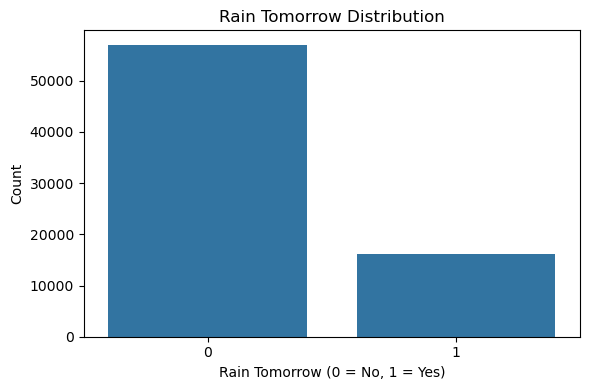

In [203]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x='Rain Tomorrow',
    data=data
)

plt.title('Rain Tomorrow Distribution')
plt.xlabel('Rain Tomorrow (0 = No, 1 = Yes)')
plt.ylabel('Count')

plt.tight_layout()

plt.savefig(
    "images/target_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

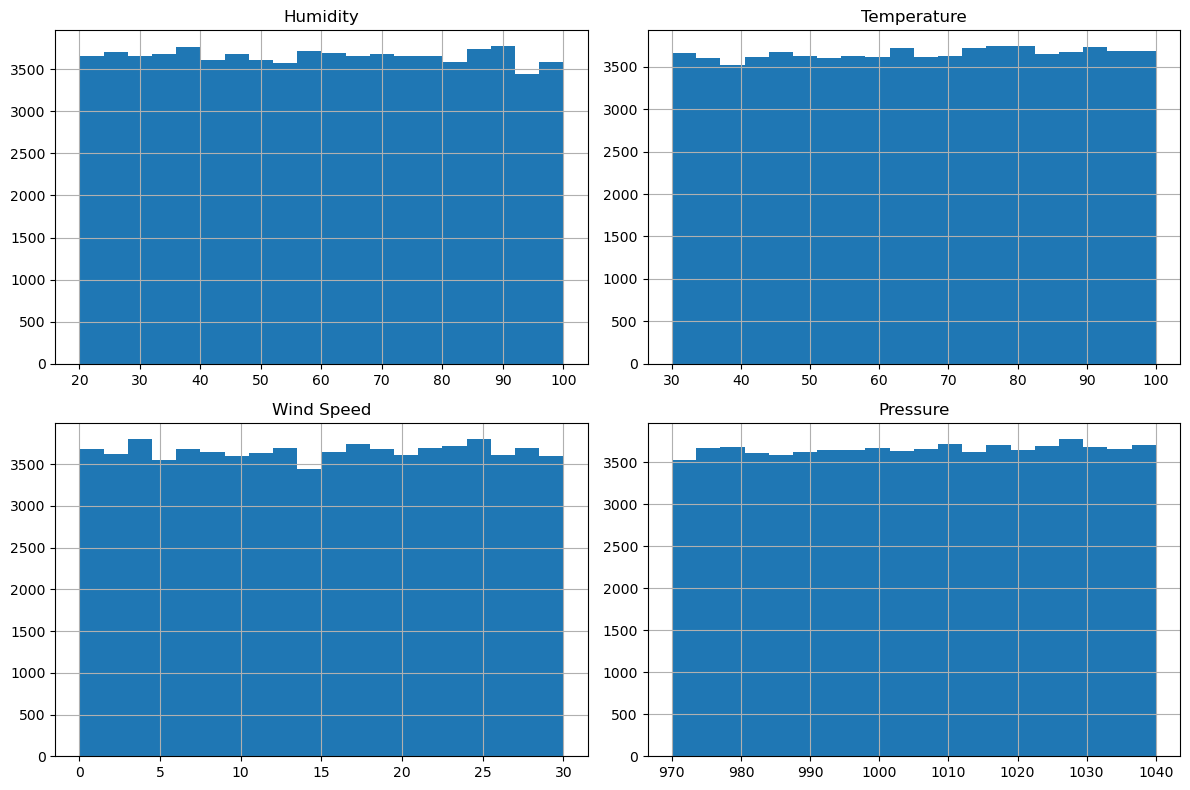

In [204]:
data[features].hist(
    figsize=(12, 8),
    bins=20
)

plt.tight_layout()

plt.savefig(
    "images/feature_distributions.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

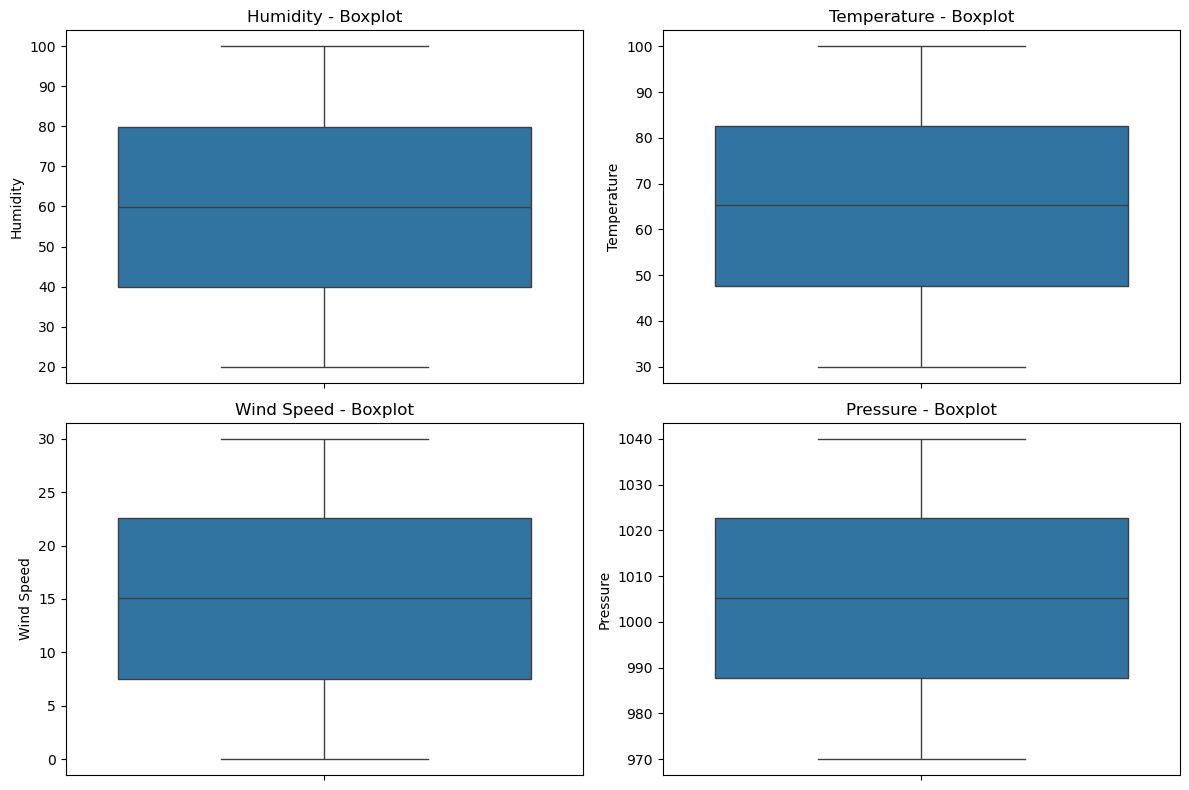

In [205]:
plt.figure(figsize=(12, 8))

for i, column in enumerate(features, 1):

    plt.subplot(2, 2, i)

    sns.boxplot(
        y=data[column]
    )

    plt.title(f'{column} - Boxplot')

plt.tight_layout()

plt.savefig(
    "images/boxplots.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

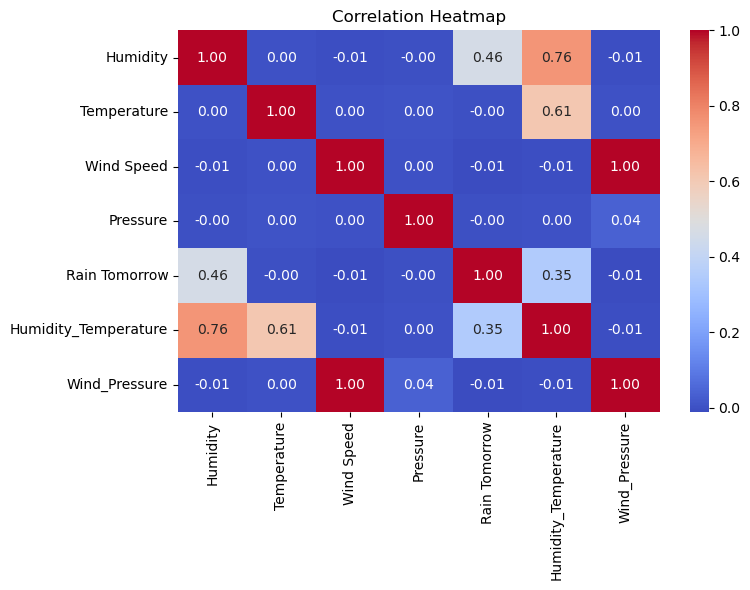

In [206]:
plt.figure(figsize=(8, 6))

correlation = data.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.tight_layout()

plt.savefig(
    "images/correlation_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

In [175]:
data['Humidity_Temperature'] = (
    data['Humidity'] * data['Temperature']
)

In [176]:
data['Wind_Pressure'] = (
    data['Wind Speed'] * data['Pressure']
)

In [177]:
data.head()

,Humidity,Temperature,Wind Speed,Pressure,Rain Tomorrow,Humidity_Temperature,Wind_Pressure
0,75.655455,87.524795,28.379506,1026.030278,0,6621.728203,29118.232312
1,28.712617,83.259325,12.436433,995.962065,0,2390.593142,12386.215248
2,64.740043,80.943050,14.184831,980.796739,1,5240.256547,13912.435634
3,59.738984,78.097552,19.444029,979.012163,0,4665.468416,19035.940471
4,34.766784,37.059963,3.689661,1031.790859,0,1288.455717,3806.958120


In [178]:
data.isnull().sum()

Humidity                0
Temperature             0
Wind Speed              0
Pressure                0
Rain Tomorrow           0
Humidity_Temperature    0
Wind_Pressure           0
dtype: int64

In [179]:
X = data[features]
y = data['Rain Tomorrow']

In [180]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (73100, 4)
y shape: (73100,)


In [181]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [182]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (58480, 4)
Testing data: (14620, 4)


In [183]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
Rain Tomorrow
0    0.779583
1    0.220417
Name: proportion, dtype: float64

Testing target distribution:
Rain Tomorrow
0    0.779617
1    0.220383
Name: proportion, dtype: float64


In [184]:
model = GaussianNB()
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [185]:
y_pred = model.predict(X_test)

In [186]:
print(y_pred[:20])

[0 0 0 1 0 0 1 1 1 1 1 1 1 1 0 1 0 0 0 0]


In [187]:
print(y_test.values[:20])

[0 0 0 0 0 0 1 1 1 1 1 0 1 0 0 0 0 0 1 0]


In [188]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.7534199726402189
Accuracy (%): 75.34199726402188


In [189]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[9381 2017]
 [1588 1634]]


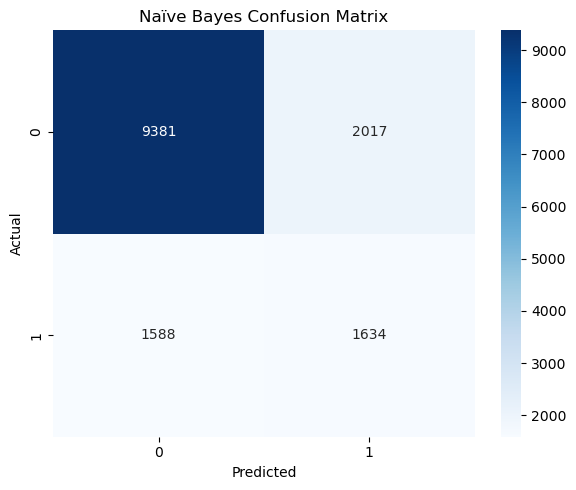

In [207]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naïve Bayes Confusion Matrix')

plt.tight_layout()

plt.savefig(
    "images/confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

In [191]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84     11398
           1       0.45      0.51      0.48      3222

    accuracy                           0.75     14620
   macro avg       0.65      0.67      0.66     14620
weighted avg       0.77      0.75      0.76     14620



In [192]:
X_engineered = data[
    [
        'Humidity',
        'Temperature',
        'Wind Speed',
        'Pressure',
        'Humidity_Temperature',
        'Wind_Pressure'
    ]
]

In [193]:
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_engineered,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [194]:
model_e = GaussianNB()

model_e.fit(X_train_e, y_train_e)

,priors,None
,var_smoothing,1e-09


In [195]:
y_pred_e = model_e.predict(X_test_e)

In [196]:
accuracy_e = accuracy_score(y_test_e, y_pred_e)

print("Engineered Feature Accuracy:",
      accuracy_e * 100)

Engineered Feature Accuracy: 75.30095759233926


In [197]:
new_weather = pd.DataFrame({
    'Humidity': [75],
    'Temperature': [28],
    'WindSpeed': [12],
    'Pressure': [1010]
})

In [198]:
new_weather = pd.DataFrame(
    [[75, 28, 12, 1010]],
    columns=features
)

print(new_weather)

   Humidity  Temperature  Wind Speed  Pressure
0        75           28          12      1010


In [199]:
prediction = model.predict(new_weather)

print("Prediction:", prediction[0])

Prediction: 0


In [201]:
probability = model.predict_proba(new_weather)

print(
    "Probability of No Rain:",
    probability[0][0] * 100,
    "%"
)

print(
    "Probability of Rain:",
    probability[0][1] * 100,
    "%"
)

Probability of No Rain: 55.91078108995824 %
Probability of Rain: 44.08921891004171 %
